# 🧪 Eksperimen Machine Learning — Credit Scoring
**Nama Siswa:** Nama-siswa  
**Dataset:** German Credit Risk (credit_scoring_raw.csv)  
**Tujuan:** Memprediksi risiko kredit (good/bad) berdasarkan data nasabah  

---


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Semua library berhasil diimport")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   seaborn    : {sns.__version__}")


✅ Semua library berhasil diimport
   pandas     : 2.3.3
   numpy      : 2.4.6
   seaborn    : 0.13.2


---
## 2. Data Loading

In [2]:
# Load dataset
RAW_PATH = '../credit_scoring_raw.csv'
df_raw = pd.read_csv(RAW_PATH, index_col=0)

print(f"✅ Dataset berhasil dimuat")
print(f"   Shape  : {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
print(f"   Kolom  : {list(df_raw.columns)}")


✅ Dataset berhasil dimuat
   Shape  : 1000 baris x 10 kolom
   Kolom  : ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']


In [3]:
# Preview 5 baris pertama
df_raw.head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
# Preview 5 baris terakhir
df_raw.tail()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad
999,27,male,2,own,moderate,moderate,4576,45,car,good


In [5]:
# Simpan salinan agar raw tidak termodifikasi
df = df_raw.copy()
print("✅ Salinan dataset dibuat (df)")


✅ Salinan dataset dibuat (df)


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Informasi Umum Dataset

In [6]:
print("=" * 55)
print("INFO DATASET")
print("=" * 55)
df.info()


INFO DATASET
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


In [7]:
print("=" * 55)
print("STATISTIK DESKRIPTIF — Kolom Numerik")
print("=" * 55)
df.describe()


STATISTIK DESKRIPTIF — Kolom Numerik


,Age,Job,Credit amount,Duration
count,1000.0000,1000.0000,1000.0000,1000.0000
mean,35.5460,1.9040,3271.2580,20.9030
std,11.3755,0.6536,2822.7369,12.0588
min,19.0000,0.0000,250.0000,4.0000
25%,27.0000,2.0000,1365.5000,12.0000
50%,33.0000,2.0000,2319.5000,18.0000
75%,42.0000,2.0000,3972.2500,24.0000
max,75.0000,3.0000,18424.0000,72.0000


In [8]:
print("=" * 55)
print("STATISTIK DESKRIPTIF — Kolom Kategorikal")
print("=" * 55)
df.describe(include='object')


STATISTIK DESKRIPTIF — Kolom Kategorikal


,Sex,Housing,Saving accounts,Checking account,Purpose,Risk
count,1000,1000,817,606,1000,1000
unique,2,3,4,3,8,2
top,male,own,little,little,car,good
freq,690,713,603,274,337,700


### 3.2 Missing Values

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing (%)', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("✅ Tidak ada missing values!")
else:
    print(f"\n⚠️  Total kolom dengan missing value: {(missing_df['Missing Count'] > 0).sum()}")


                  Missing Count  Missing (%)
Checking account            394      39.4000
Saving accounts             183      18.3000

⚠️  Total kolom dengan missing value: 2


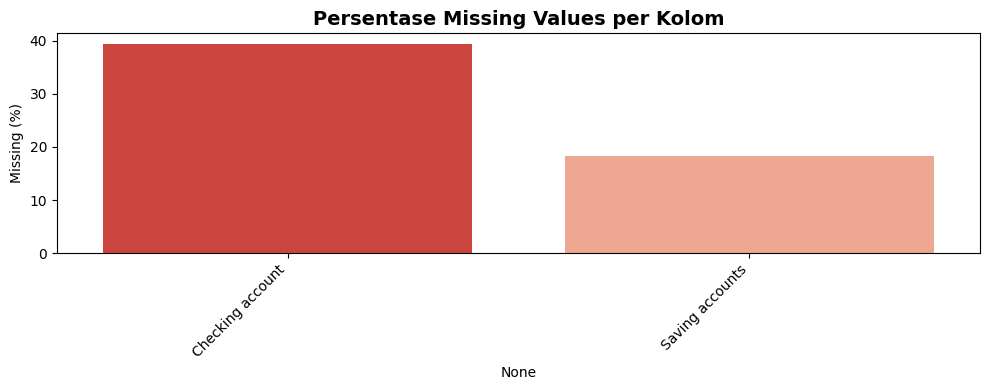

In [10]:
# Visualisasi missing values
plt.figure(figsize=(10, 4))
missing_vis = missing_df[missing_df['Missing Count'] > 0]
if len(missing_vis) > 0:
    sns.barplot(x=missing_vis.index, y='Missing (%)', data=missing_vis, palette='Reds_r')
    plt.title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
    plt.ylabel('Missing (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("✅ Tidak ada missing values — tidak perlu visualisasi")


### 3.3 Distribusi Target

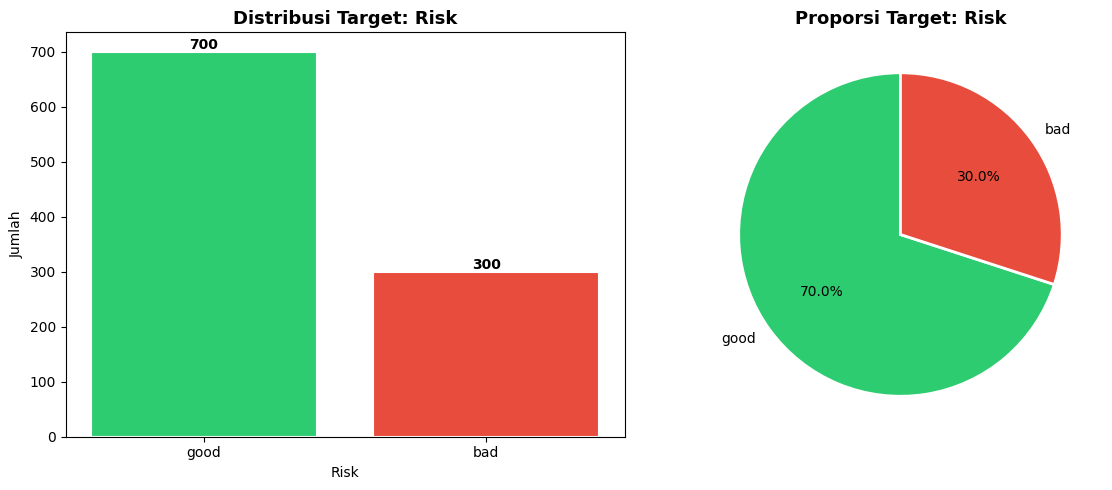


Distribusi Target:
  good: 700 (70.0%)
  bad: 300 (30.0%)


In [11]:
TARGET = 'Risk'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
vc = df[TARGET].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title(f'Distribusi Target: {TARGET}', fontsize=13, fontweight='bold')
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Jumlah')
for i, (idx, val) in enumerate(zip(vc.index, vc.values)):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title(f'Proporsi Target: {TARGET}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nDistribusi Target:")
for label, count in vc.items():
    print(f"  {label}: {count} ({count/len(df)*100:.1f}%)")


In [12]:
print(df.columns.tolist())

['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']


### 3.4 Distribusi Fitur Numerik

Kolom numerik (4): ['Age', 'Job', 'Credit amount', 'Duration']


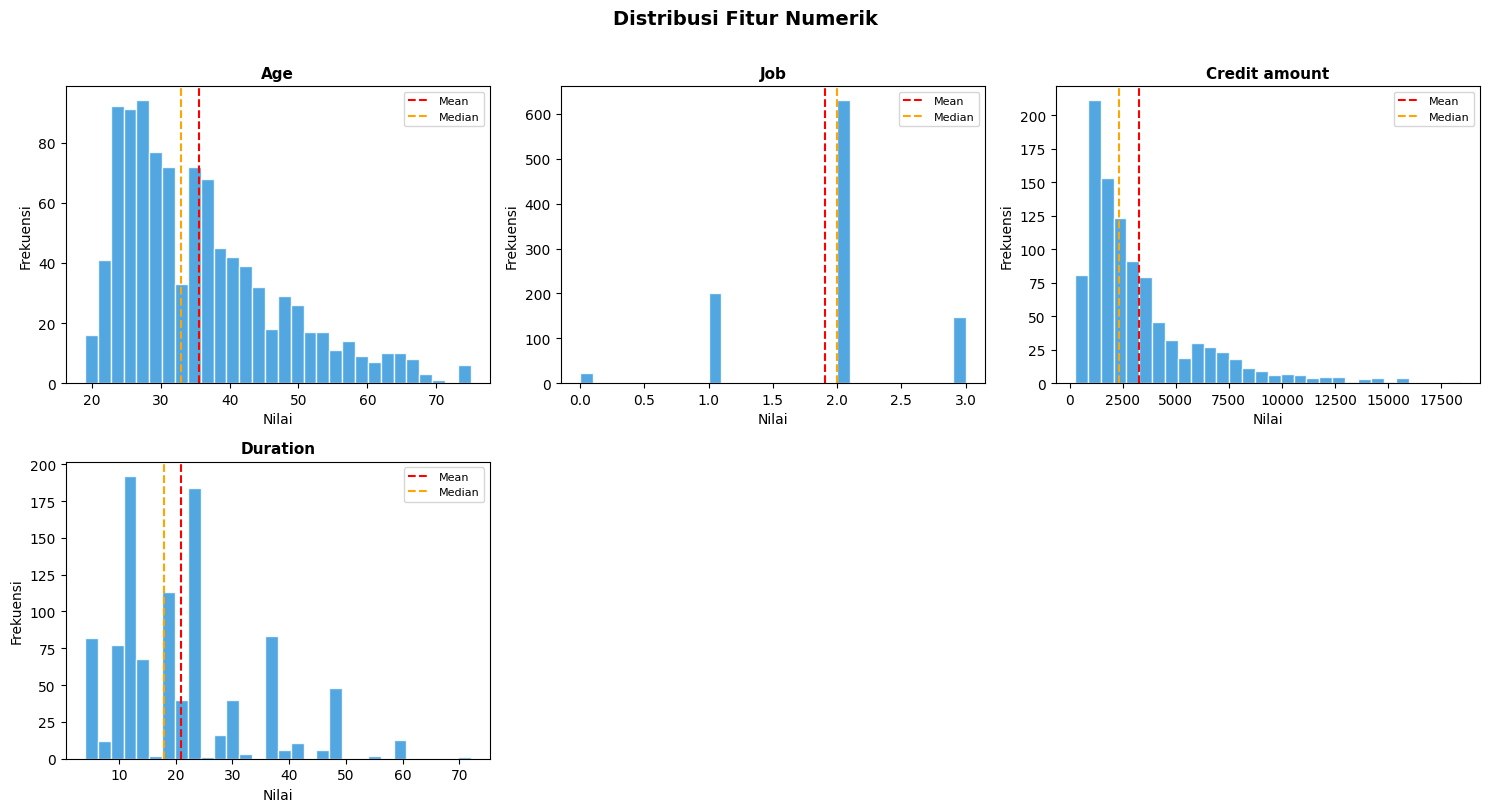

In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Kolom numerik ({len(num_cols)}): {num_cols}")

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label='Median')
    axes[i].legend(fontsize=8)

# Sembunyikan axes yang tidak terpakai
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.5 Distribusi Fitur Kategorikal

Kolom kategorikal (5): ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


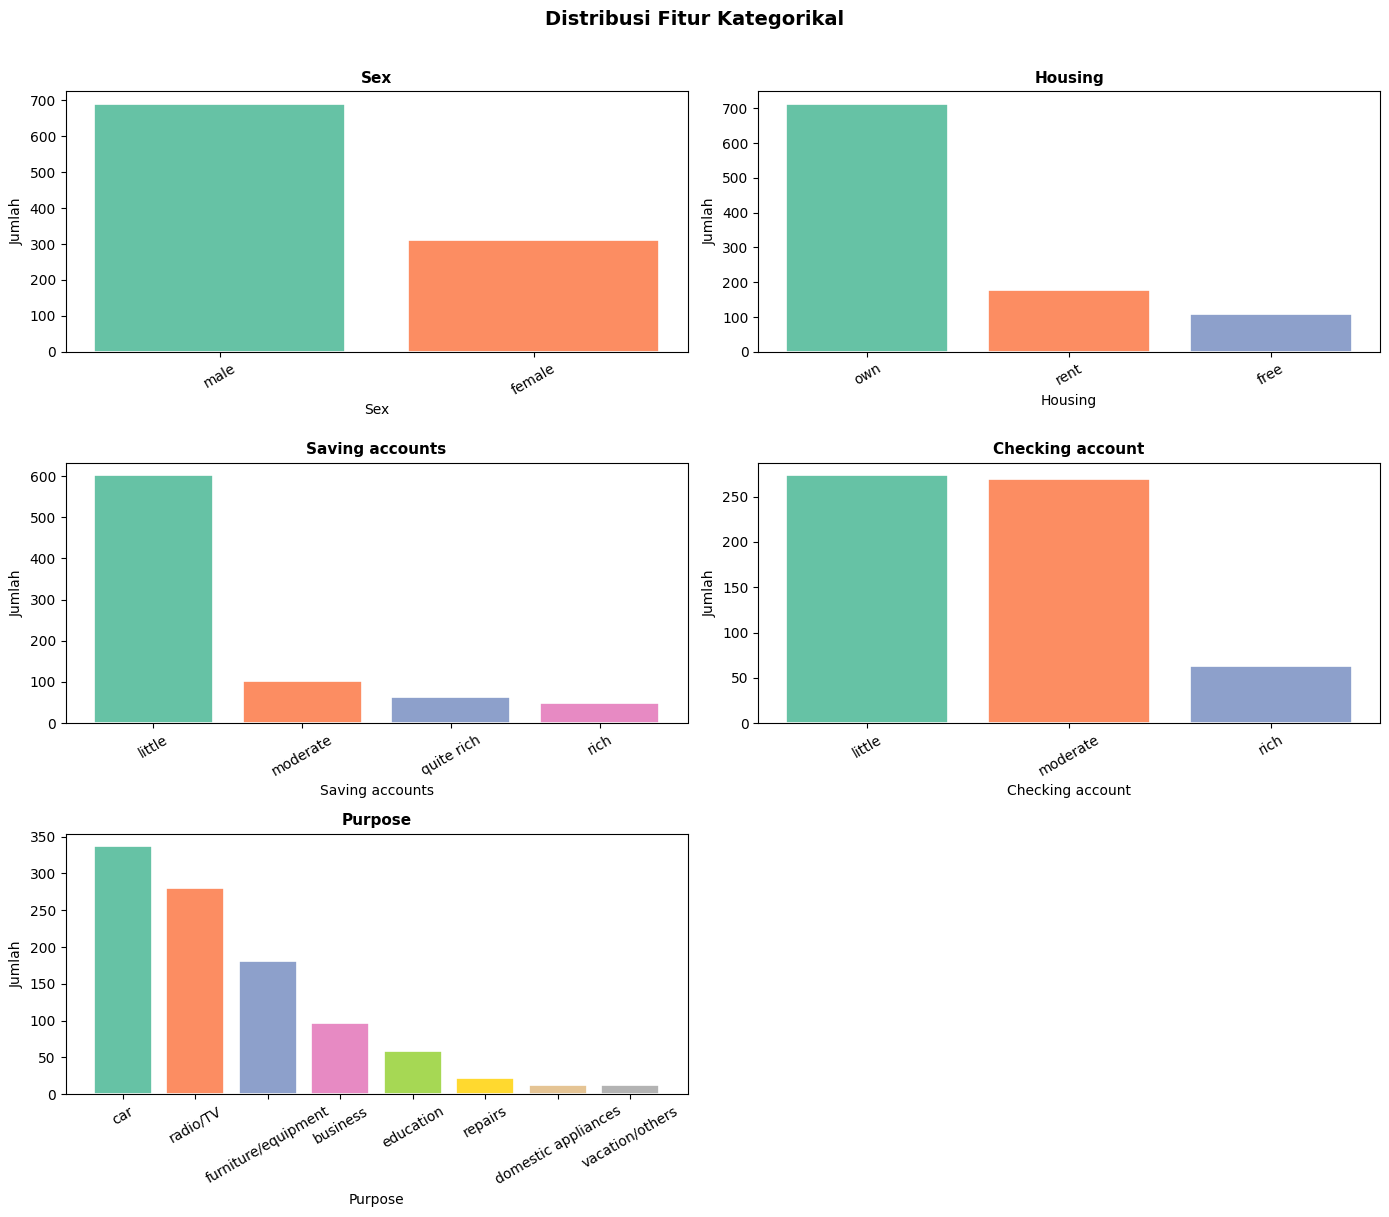

In [14]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols_no_target = [c for c in cat_cols if c != TARGET]
print(f"Kolom kategorikal ({len(cat_cols_no_target)}): {cat_cols_no_target}")

n_cols = 2
n_rows = (len(cat_cols_no_target) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols_no_target):
    vc = df[col].value_counts()
    axes[i].bar(vc.index.astype(str), vc.values,
                color=sns.color_palette('Set2', len(vc)),
                edgecolor='white', linewidth=1.2)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.6 Korelasi Antar Fitur Numerik

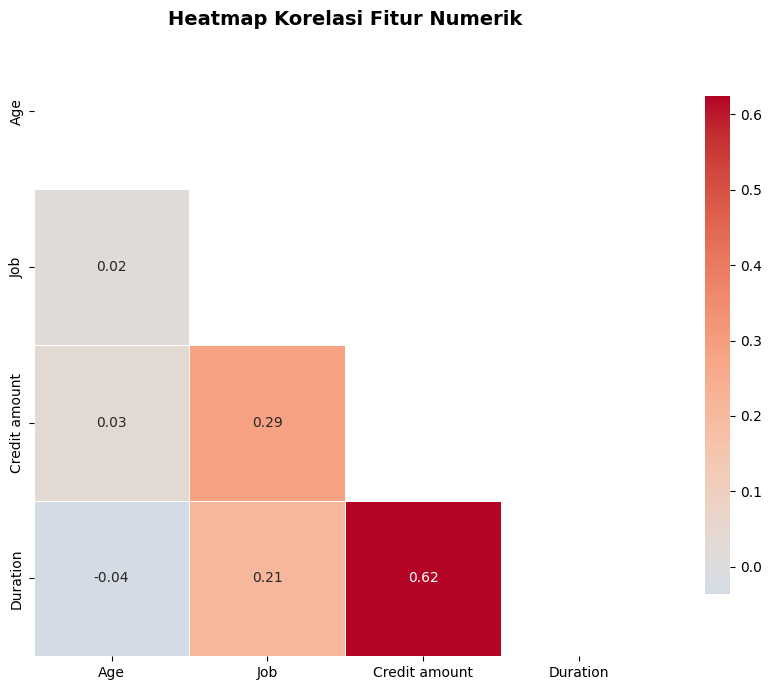

In [15]:
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    square=True, cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.7 Hubungan Fitur dengan Target

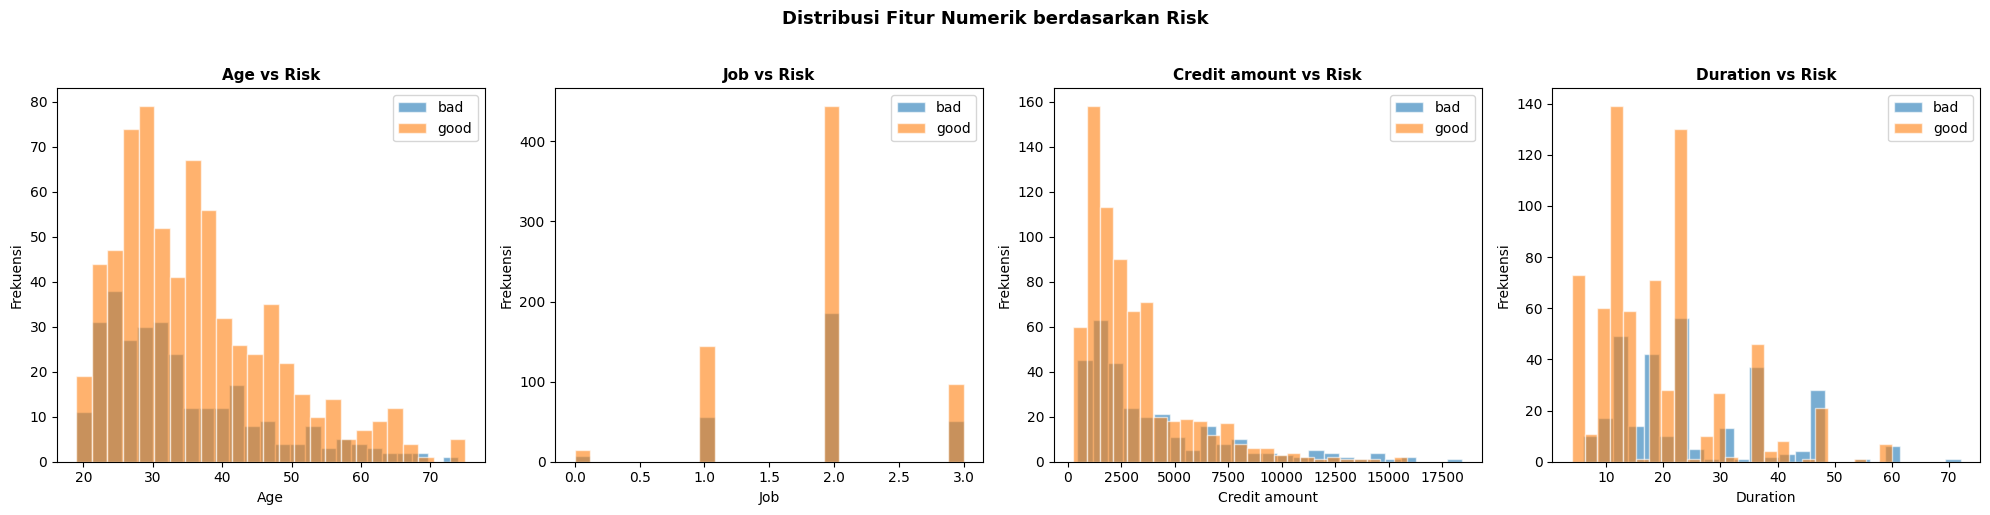

In [16]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 5))
if len(num_cols) == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    for label, grp in df.groupby(TARGET):
        axes[i].hist(grp[col], bins=25, alpha=0.6, label=label, edgecolor='white')
    axes[i].set_title(f'{col} vs {TARGET}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend()

plt.suptitle(f'Distribusi Fitur Numerik berdasarkan {TARGET}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 3.8 Outlier Detection (Boxplot)

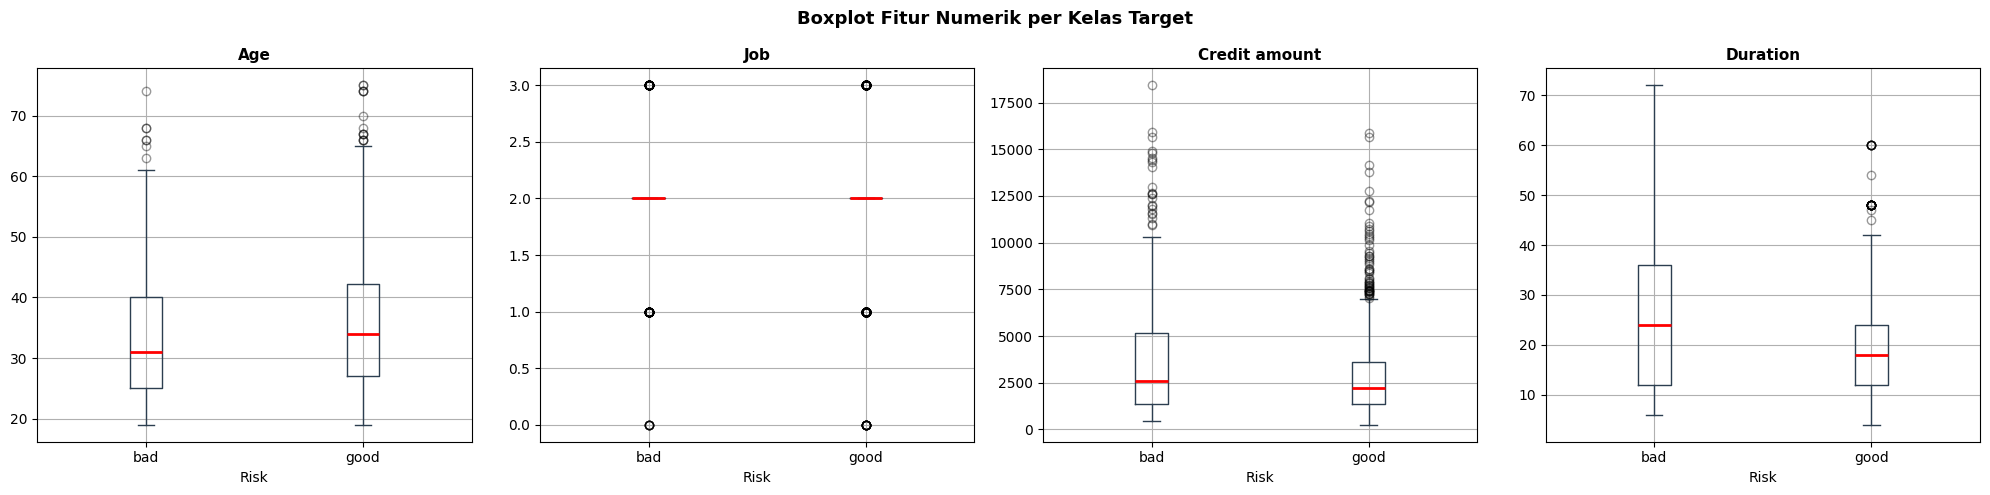

In [17]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 5))
if len(num_cols) == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by=TARGET, ax=axes[i],
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='#2c3e50'),
               capprops=dict(color='#2c3e50'),
               flierprops=dict(marker='o', color='red', alpha=0.4))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(TARGET)

plt.suptitle('Boxplot Fitur Numerik per Kelas Target',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. Data Preprocessing

### 4.1 Hapus Duplikat

In [18]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
removed = before - after

print(f"Sebelum : {before} baris")
print(f"Setelah : {after} baris")
print(f"Dihapus : {removed} baris duplikat")
print("✅ Selesai menghapus duplikat")


Sebelum : 1000 baris
Setelah : 1000 baris
Dihapus : 0 baris duplikat
✅ Selesai menghapus duplikat


### 4.2 Handle Missing Values

In [19]:
for col in df.columns:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        if df[col].dtype in ['float64', 'int64']:
            fill_val = df[col].median()
            df[col] = df[col].fillna(fill_val)
            print(f"  [{col}] diisi median = {fill_val:.4f}  ({n_missing} nilai)")
        else:
            fill_val = df[col].mode()[0]
            df[col] = df[col].fillna(fill_val)  # ← pastikan fill_val bukan mode_val
            print(f"  [{col}] diisi modus = '{fill_val}'  ({n_missing} nilai)")

print(f"\nTotal missing setelah penanganan: {df.isnull().sum().sum()}")
print("✅ Selesai menangani missing values")

  [Saving accounts] diisi modus = 'little'  (183 nilai)
  [Checking account] diisi modus = 'little'  (394 nilai)

Total missing setelah penanganan: 0
✅ Selesai menangani missing values


### 4.3 Encoding Fitur Kategorikal

In [20]:
encoders = {}
TARGET = 'Risk'

for col in df.select_dtypes(include='object').columns:
    if col == TARGET:
        continue
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"  [{col}] → {list(le.classes_)}")

print(f"\n✅ Selesai encoding {len(encoders)} kolom kategorikal")


  [Sex] → ['female', 'male']
  [Housing] → ['free', 'own', 'rent']
  [Saving accounts] → ['little', 'moderate', 'quite rich', 'rich']
  [Checking account] → ['little', 'moderate', 'rich']
  [Purpose] → ['business', 'car', 'domestic appliances', 'education', 'furniture/equipment', 'radio/TV', 'repairs', 'vacation/others']

✅ Selesai encoding 5 kolom kategorikal


### 4.4 Encoding Target

In [21]:
le_target = LabelEncoder()
df[TARGET] = le_target.fit_transform(df[TARGET].astype(str))

print(f"Kelas target : {list(le_target.classes_)}")
print(f"Mapping      : {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
print("✅ Target berhasil di-encode")


Kelas target : ['bad', 'good']
Mapping      : {'bad': np.int64(0), 'good': np.int64(1)}
✅ Target berhasil di-encode


### 4.5 Menghapus Outlier (IQR Method)

In [22]:
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
num_features = [c for c in num_features if c != TARGET]

before = len(df)
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

after = len(df)
print(f"Sebelum : {before} baris")
print(f"Setelah : {after} baris")
print(f"Dihapus : {before - after} baris outlier")
print("✅ Selesai menghapus outlier")


Sebelum : 1000 baris
Setelah : 308 baris
Dihapus : 692 baris outlier
✅ Selesai menghapus outlier


### 4.6 Split Data (Train/Test)

In [23]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total data : {len(df)}")
print(f"X_train    : {X_train.shape}")
print(f"X_test     : {X_test.shape}")
print(f"\nDistribusi y_train : {dict(y_train.value_counts())}")
print(f"Distribusi y_test  : {dict(y_test.value_counts())}")
print("✅ Data berhasil di-split")


Total data : 308
X_train    : (246, 9)
X_test     : (62, 9)

Distribusi y_train : {1: np.int64(185), 0: np.int64(61)}
Distribusi y_test  : {1: np.int64(46), 0: np.int64(16)}
✅ Data berhasil di-split


### 4.7 Feature Scaling (StandardScaler)

In [24]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Statistik X_train setelah scaling:")
print(X_train_scaled.describe().loc[['mean', 'std']].round(4))
print("\n✅ Feature scaling selesai")


Statistik X_train setelah scaling:
         Age    Sex    Job  Housing  Saving accounts  Checking account  \
mean -0.0000 0.0000 0.0000   0.0000           0.0000           -0.0000   
std   1.0020 1.0020 0.0000   0.0000           0.0000            1.0020   

      Credit amount  Duration  Purpose  
mean        -0.0000   -0.0000  -0.0000  
std          1.0020    1.0020   1.0020  

✅ Feature scaling selesai


### 4.8 Simpan Dataset Hasil Preprocessing

In [25]:
OUTPUT_DIR = './credit_scoring_preprocessing'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Gabungkan kembali X + y
train_df = X_train_scaled.copy()
train_df[TARGET] = y_train.values

test_df = X_test_scaled.copy()
test_df[TARGET] = y_test.values

# Simpan ke CSV
train_df.to_csv(f'{OUTPUT_DIR}/train.csv', index=False)
test_df.to_csv(f'{OUTPUT_DIR}/test.csv', index=False)

# Simpan scaler & encoder
artifact_dir = f'{OUTPUT_DIR}/artifacts'
os.makedirs(artifact_dir, exist_ok=True)
joblib.dump(scaler,      f'{artifact_dir}/scaler.pkl')
joblib.dump(encoders,    f'{artifact_dir}/encoders.pkl')
joblib.dump(le_target,   f'{artifact_dir}/target_encoder.pkl')

print(f"✅ Dataset disimpan ke: {OUTPUT_DIR}/")
print(f"   train.csv  : {train_df.shape}")
print(f"   test.csv   : {test_df.shape}")
print(f"   artifacts/ : scaler.pkl, encoders.pkl, target_encoder.pkl")


✅ Dataset disimpan ke: ./credit_scoring_preprocessing/
   train.csv  : (246, 10)
   test.csv   : (62, 10)
   artifacts/ : scaler.pkl, encoders.pkl, target_encoder.pkl


---
## 5. Validasi Hasil Preprocessing

In [26]:
# Verifikasi file tersimpan
for fname in ['train.csv', 'test.csv']:
    path = f'{OUTPUT_DIR}/{fname}'
    _df  = pd.read_csv(path)
    print(f"✅ {fname:15s} → shape: {_df.shape}  |  missing: {_df.isnull().sum().sum()}")


✅ train.csv       → shape: (246, 10)  |  missing: 0
✅ test.csv        → shape: (62, 10)  |  missing: 0


In [27]:
# Quick model check untuk memastikan data siap dilatih
model_check = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model_check.fit(X_train_scaled, y_train)
acc = accuracy_score(y_test, model_check.predict(X_test_scaled))

print(f"\n🎯 Sanity-check Accuracy (RandomForest 50 trees): {acc:.4f}")
print(f"\n{'='*50}")
print("✅ Preprocessing selesai. Data siap untuk pelatihan model!")
print(f"{'='*50}")



🎯 Sanity-check Accuracy (RandomForest 50 trees): 0.7097

✅ Preprocessing selesai. Data siap untuk pelatihan model!


---
## ✅ Ringkasan Preprocessing

| Tahap | Keterangan |
|---|---|
| Data Loading | Memuat `credit_scoring_raw.csv` |
| EDA | Distribusi, missing value, korelasi, outlier visualisasi |
| Hapus Duplikat | Menghapus baris duplikat |
| Handle Missing Value | Median (numerik) / Modus (kategorikal) |
| Encoding Kategorikal | LabelEncoder untuk semua fitur object |
| Encoding Target | LabelEncoder (good=0, bad=1) |
| Hapus Outlier | IQR Method |
| Train/Test Split | 80% train, 20% test, stratify |
| Feature Scaling | StandardScaler (fit on train only) |
| Simpan Output | `train.csv`, `test.csv`, `artifacts/` |
